## Data Cleaning

The dataset contains missing values and mild outliers that must be addressed before visualization.

**Outlier Handling:**
- CO2 Emissions: 5 rows share an identical erroneous value (~449,100) across different countries, replaced with NaN
- Methane, Nitrous, GDP, Population: Per-country z-score outlier detection (z > 3), flagged values replaced with NaN

**Missing Value Handling:**
- Linear interpolation grouped by country (time-series aware), with backward/forward fill for edge cases
- Justification: Since the data is a time series per country (2000–2024), interpolation preserves temporal trends better than median imputation. Missing values represent ~2% of each column, so imputation doesn't skew the data significantly.

In [84]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [85]:
# load the dataset
df = pd.read_csv('CO2_Emissions_Sample.csv')

# summary before cleaning
print("=== BEFORE CLEANING ===")
print(f"Missing values:\n{df.isnull().sum()}")
print(f"\n{df.describe().round(2)}")

# replace erroneous CO2 values with NaN
df.loc[df['CO2_Emissions'] > 200000, 'CO2_Emissions'] = np.nan

# flag per-country outliers using z-score (z > 3), replace with NaN
for col in ['Methane_Emissions', 'Nitrous_Emissions', 'GDP', 'Population']:
    z = df.groupby('Country')[col].transform(lambda x: (x - x.mean()) / x.std())
    df.loc[z.abs() > 3, col] = np.nan

# interpolate missing values by country
df = df.sort_values(['Country', 'Year']).reset_index(drop=True)
numeric_cols = ['CO2_Emissions', 'Methane_Emissions', 'Nitrous_Emissions', 'GDP', 'Population']
df[numeric_cols] = df.groupby('Country')[numeric_cols].transform(
    lambda x: x.interpolate(method='linear').bfill().ffill()
)

# summary after cleaning
print("\n=== AFTER CLEANING ===")
print(f"Missing values:\n{df.isnull().sum()}")
print(f"\n{df.describe().round(2)}")

# save cleaned dataset
df.to_csv('CO2_Emissions_Sample.csv', index=False)
print("\nCleaned dataset saved.")

=== BEFORE CLEANING ===
Missing values:
Country               0
Continent             0
Year                  0
CO2_Emissions        20
Methane_Emissions    20
Nitrous_Emissions     0
GDP                  20
Population            0
dtype: int64

          Year  CO2_Emissions  Methane_Emissions  Nitrous_Emissions       GDP  \
count  1000.00         980.00             980.00            1000.00    980.00   
mean   2012.00       10886.95             890.86             351.11  28903.59   
std       7.21       32934.85            1342.64             477.71  13688.09   
min    2000.00          20.53               1.33               1.13     23.19   
25%    2006.00        2729.86             259.93             103.16  19401.38   
50%    2012.00        6352.34             575.90             227.49  29396.48   
75%    2018.00       10169.48            1043.65             424.17  37416.47   
max    2024.00      449100.48           25825.33            6897.60  81810.70   

         Population  
co

## Part A - Visualizing Amounts

**A1:** Bar chart showing the top 10 countries by CO₂ emissions in 2020.

**A2:** Stacked bar chart showing CO₂, Methane, and Nitrous emissions for the same countries.

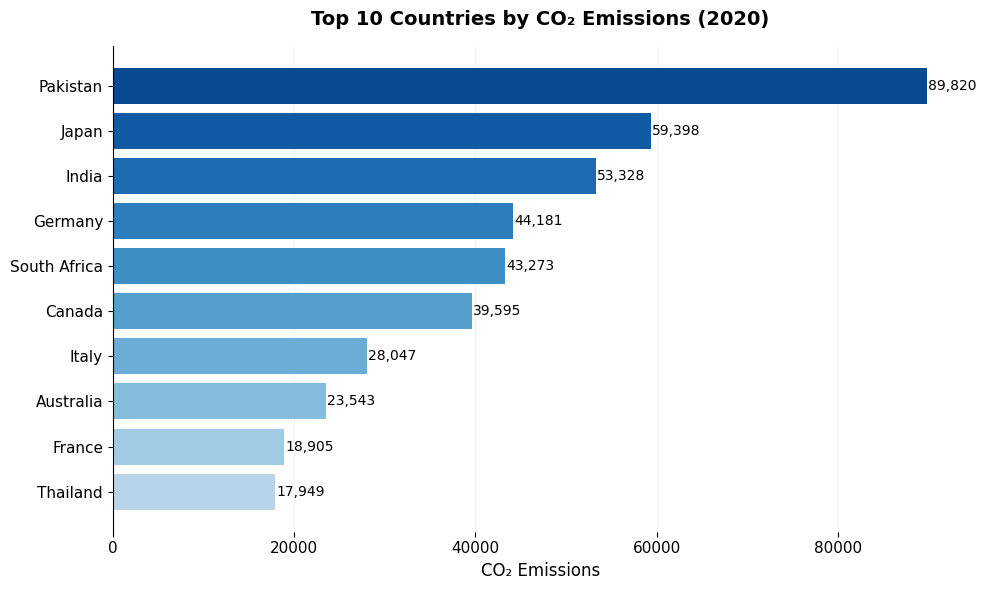

In [86]:
# filter for 2020 and get top 10 countries by CO2 emissions
df_2020 = df[df['Year'] == 2020]
top10 = df_2020.nlargest(10, 'CO2_Emissions')

# bar chart: top 10 countries by CO2 emissions in 2020
fig, ax = plt.subplots(figsize=(10, 6))

# sequential gradient: darkest shade = highest emissions (top of chart)
colors = plt.cm.Blues(np.linspace(0.3, 0.9, len(top10)))[::-1]
bars = ax.barh(top10['Country'], top10['CO2_Emissions'], color=colors)

# value labels beside bars
for bar in bars:
    width = bar.get_width()
    ax.text(width + 100, bar.get_y() + bar.get_height()/2,
            f'{width:,.0f}', ha='left', va='center', fontsize=10)

ax.invert_yaxis()
ax.set_xlim(0)
ax.set_xlabel('CO₂ Emissions', fontsize=12)
ax.set_title('Top 10 Countries by CO₂ Emissions (2020)', fontsize=14, fontweight='bold', pad=15)
ax.tick_params(axis='both', labelsize=11)
ax.xaxis.grid(True, linestyle='-', alpha=0.15)
ax.set_axisbelow(True)
for spine in ['top', 'right', 'bottom']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

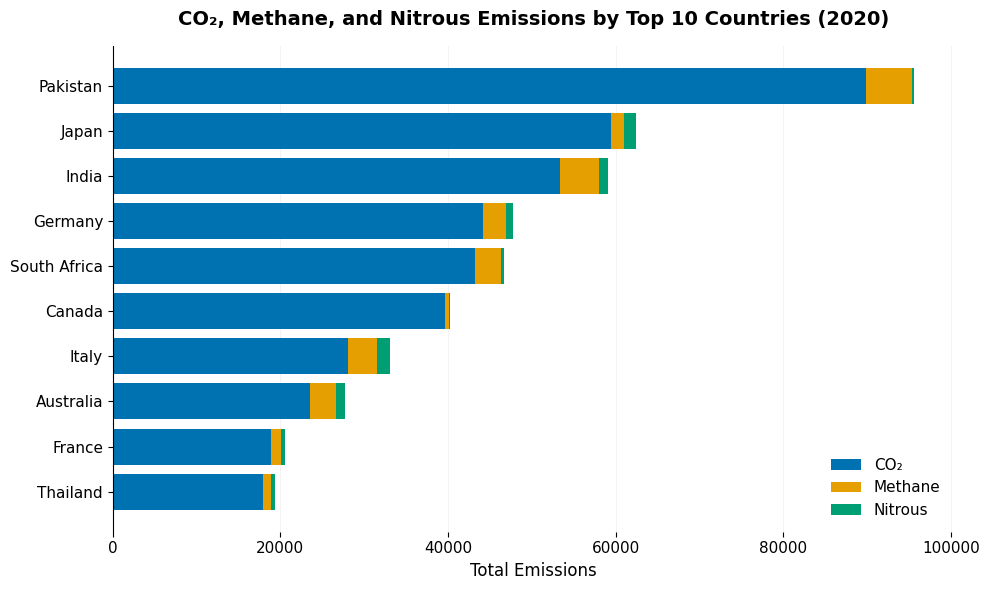

In [87]:
# stacked bar chart: CO2, methane, and nitrous for top 10 countries
# using Okabe-Ito palette, colourblind friendly
fig, ax = plt.subplots(figsize=(10, 6))

countries = top10['Country'].values
co2 = top10['CO2_Emissions'].values
methane = top10['Methane_Emissions'].values
nitrous = top10['Nitrous_Emissions'].values

ax.barh(countries, co2, label='CO₂', color='#0072B2')
ax.barh(countries, methane, left=co2, label='Methane', color='#E69F00')
ax.barh(countries, nitrous, left=co2 + methane, label='Nitrous', color='#009E73')

ax.invert_yaxis()
ax.set_xlim(0)
ax.set_xlabel('Total Emissions', fontsize=12)
ax.set_title('CO₂, Methane, and Nitrous Emissions by Top 10 Countries (2020)',
             fontsize=14, fontweight='bold', pad=15)
ax.legend(loc='lower right', frameon=False, fontsize=11)
ax.tick_params(axis='both', labelsize=11)
ax.xaxis.grid(True, linestyle='-', alpha=0.15)
ax.set_axisbelow(True)
for spine in ['top', 'right', 'bottom']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

## Part B - Visualizing Associations

**B1:** Scatter plot: GDP vs CO₂ emissions, colour = Continent.

**B2:** Bubble chart: GDP vs CO₂, bubble size = Population.

**B3:** Correlogram: correlation matrix for CO₂, GDP, Methane, Nitrous.

**B4:** Comment on any visible patterns or relationships.

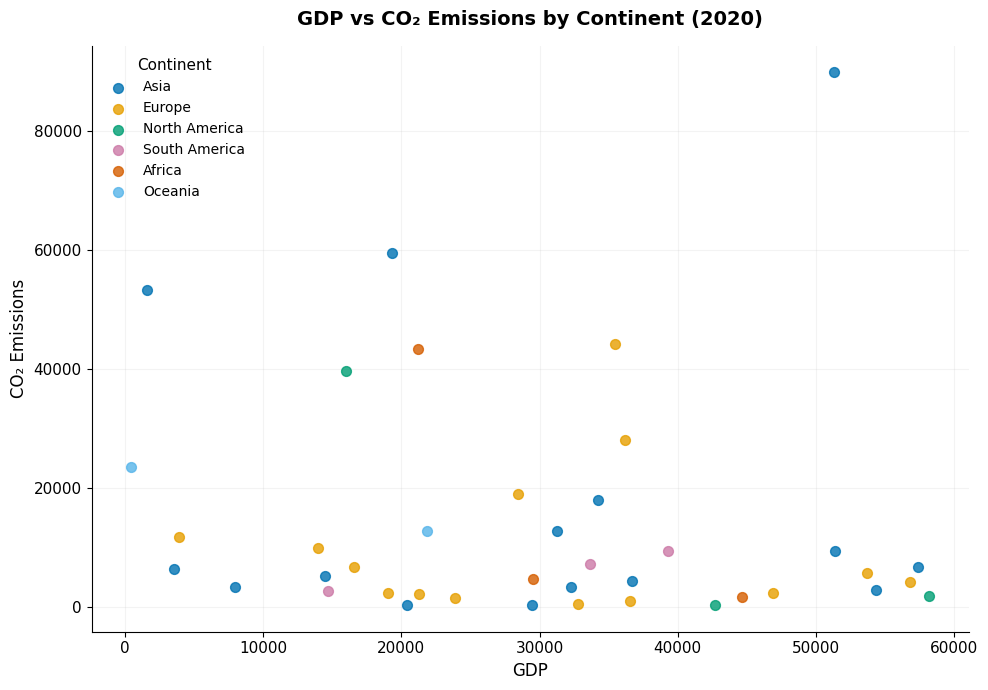

In [88]:
# scatter plot: GDP vs CO2 emissions, coloured by continent
# using Okabe-Ito palette, colourblind friendly
fig, ax = plt.subplots(figsize=(10, 7))

continent_colors = {
    'Asia': '#0072B2',
    'Europe': '#E69F00',
    'North America': '#009E73',
    'South America': '#CC79A7',
    'Africa': '#D55E00',
    'Oceania': '#56B4E9'
}

for continent, color in continent_colors.items():
    subset = df_2020[df_2020['Continent'] == continent]
    ax.scatter(subset['GDP'], subset['CO2_Emissions'],
               c=color, label=continent, s=50, alpha=0.8)

ax.set_xlabel('GDP', fontsize=12)
ax.set_ylabel('CO₂ Emissions', fontsize=12)
ax.set_title('GDP vs CO₂ Emissions by Continent (2020)', fontsize=14, fontweight='bold', pad=15)
ax.legend(title='Continent', frameon=False, fontsize=10, title_fontsize=11)
ax.tick_params(axis='both', labelsize=11)
ax.xaxis.grid(True, linestyle='-', alpha=0.15)
ax.yaxis.grid(True, linestyle='-', alpha=0.15)
ax.set_axisbelow(True)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

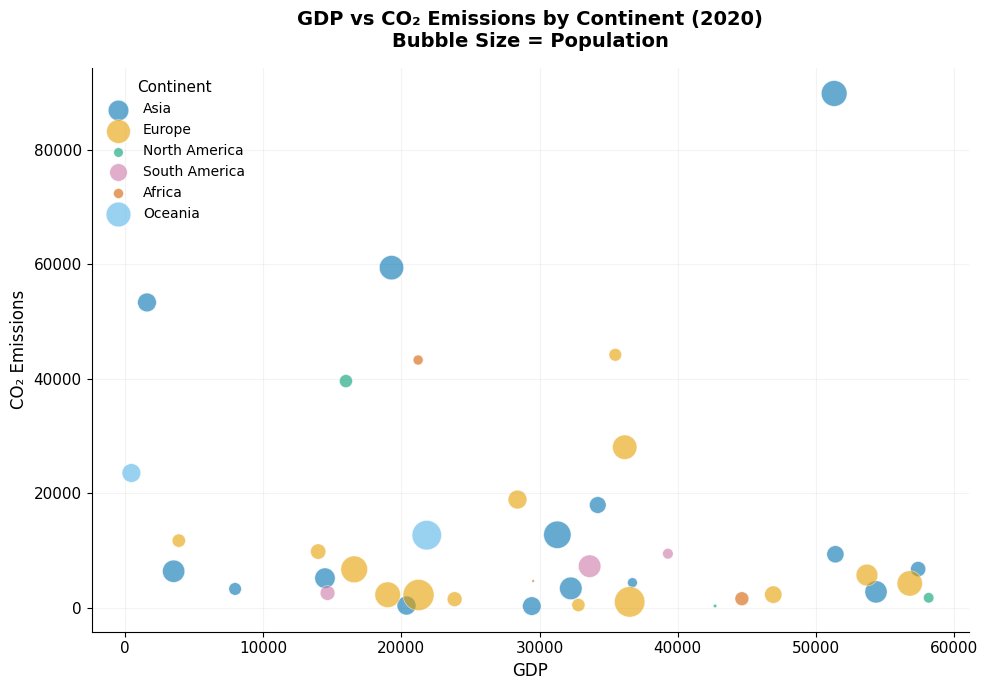

In [89]:
# bubble chart: GDP vs CO2, bubble size = population
fig, ax = plt.subplots(figsize=(10, 7))

# scale population to reasonable bubble sizes
pop_scaled = df_2020['Population'] / df_2020['Population'].max() * 500

for continent, color in continent_colors.items():
    subset = df_2020[df_2020['Continent'] == continent]
    sizes = pop_scaled[subset.index]
    ax.scatter(subset['GDP'], subset['CO2_Emissions'],
               s=sizes, c=color, label=continent, alpha=0.6, edgecolors='white', linewidths=0.5)

ax.set_xlabel('GDP', fontsize=12)
ax.set_ylabel('CO₂ Emissions', fontsize=12)
ax.set_title('GDP vs CO₂ Emissions by Continent (2020)\nBubble Size = Population',
             fontsize=14, fontweight='bold', pad=15)
ax.legend(title='Continent', frameon=False, fontsize=10, title_fontsize=11)
ax.tick_params(axis='both', labelsize=11)
ax.xaxis.grid(True, linestyle='-', alpha=0.15)
ax.yaxis.grid(True, linestyle='-', alpha=0.15)
ax.set_axisbelow(True)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

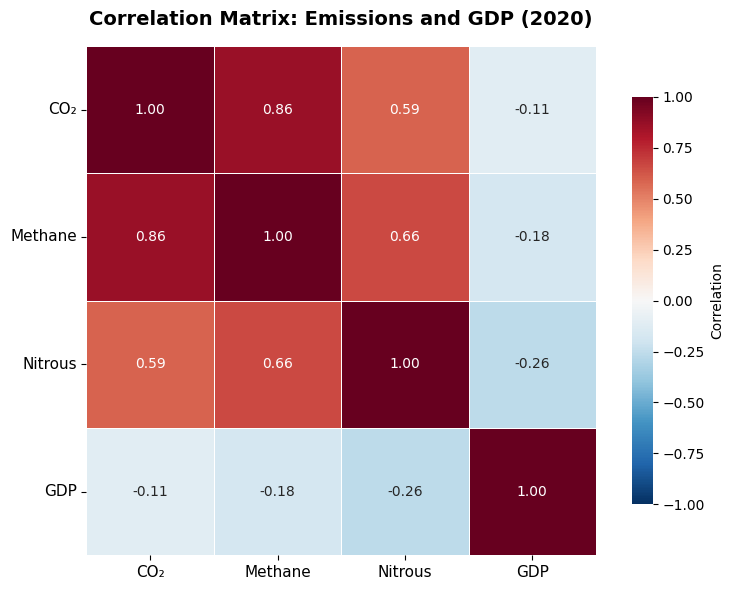

In [90]:
# correlogram: correlation matrix for CO2, GDP, Methane, Nitrous
import seaborn as sns

corr_cols = ['CO2_Emissions', 'Methane_Emissions', 'Nitrous_Emissions', 'GDP']
corr_matrix = df_2020[corr_cols].corr()

# shorter labels for readability
short_labels = ['CO₂', 'Methane', 'Nitrous', 'GDP']
corr_matrix.index = short_labels
corr_matrix.columns = short_labels

fig, ax = plt.subplots(figsize=(8, 6))

# using a perceptually uniform diverging colourmap, colourblind friendly
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True,
            linewidths=0.5, linecolor='white',
            cbar_kws={'shrink': 0.8, 'label': 'Correlation'},
            ax=ax)

ax.set_title('Correlation Matrix: Emissions and GDP (2020)', fontsize=14, fontweight='bold', pad=15)
ax.tick_params(axis='both', labelsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.show()

### B4: Patterns and Relationships

**GDP vs CO₂ Emissions:** The scatter plot shows a weak positive association between GDP and CO₂ emissions. Countries with higher GDP do not necessarily produce more CO₂, suggesting that economic output alone does not determine emission levels. Other factors like energy mix, industrial composition, and population size likely play a role.

**Continental Clustering:** European and Asian countries are spread across a wide range of both GDP and CO₂ values, while African and South American countries tend to cluster in the lower ranges of both variables. Oceania sits in the mid-range for GDP but relatively low for emissions.

**Bubble Chart (Population):** When population is encoded as bubble size, it becomes clear that some high-emission countries simply have large populations rather than high per-capita emissions. Population appears to be a confounding variable in the GDP-CO₂ relationship.

**Correlogram:** The correlation matrix reveals moderate positive correlations between CO₂ and Methane emissions, which is expected since both are driven by fossil fuel combustion and industrial activity. GDP shows a weaker correlation with emissions overall, reinforcing the scatter plot observation that wealth and emissions are not tightly linked at the country level. Nitrous emissions show the weakest associations with the other variables.

## Part C - Visualizing Proportions

**C1:** Stacked bar chart: relative share of CO₂, Methane, and Nitrous emissions by continent in 2020.

**C2:** Treemap: emission contributions by region.

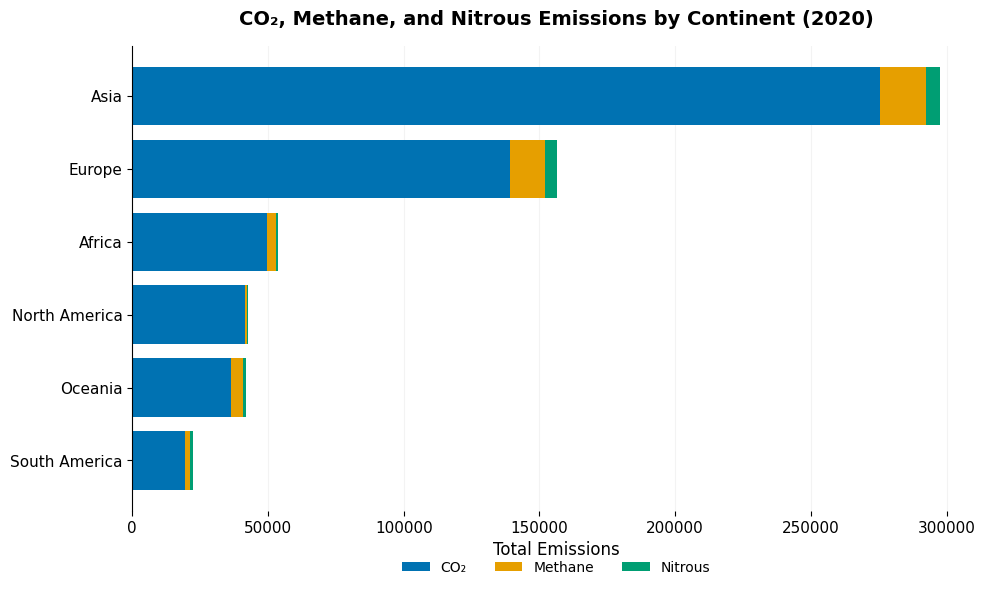

In [91]:
# stacked bar chart: CO2, Methane, and Nitrous emissions by continent in 2020
# using absolute values so both composition and scale are visible
# Okabe-Ito palette, colourblind friendly
continent_emissions = df_2020.groupby('Continent')[['CO2_Emissions', 'Methane_Emissions', 'Nitrous_Emissions']].sum()
continent_emissions = continent_emissions.sort_values('CO2_Emissions')

fig, ax = plt.subplots(figsize=(10, 6))

continents = continent_emissions.index
co2 = continent_emissions['CO2_Emissions'].values
methane = continent_emissions['Methane_Emissions'].values
nitrous = continent_emissions['Nitrous_Emissions'].values

ax.barh(continents, co2, label='CO₂', color='#0072B2')
ax.barh(continents, methane, left=co2, label='Methane', color='#E69F00')
ax.barh(continents, nitrous, left=co2 + methane, label='Nitrous', color='#009E73')

ax.set_xlim(0)
ax.set_xlabel('Total Emissions', fontsize=12)
ax.set_title('CO₂, Methane, and Nitrous Emissions by Continent (2020)',
             fontsize=14, fontweight='bold', pad=15)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.08), ncol=3, frameon=False, fontsize=10)
ax.tick_params(axis='both', labelsize=11)
ax.xaxis.grid(True, linestyle='-', alpha=0.15)
ax.set_axisbelow(True)
for spine in ['top', 'right', 'bottom']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

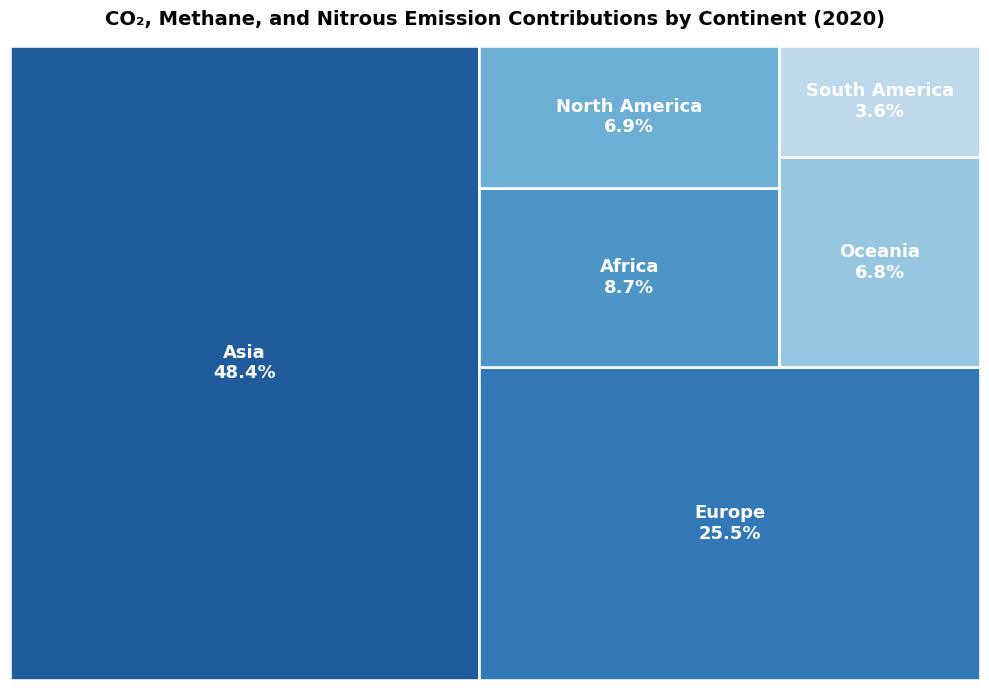

In [92]:
# treemap: CO2, Methane, and Nitrous emission contributions by continent
import squarify

# total emissions per continent (CO2 + Methane + Nitrous)
continent_total = df_2020.groupby('Continent')[['CO2_Emissions', 'Methane_Emissions', 'Nitrous_Emissions']].sum()
continent_total['Total'] = continent_total.sum(axis=1)
continent_total = continent_total.sort_values('Total', ascending=False)

# colourblind friendly palette, sequential gradient for proportional feel
treemap_colors = plt.cm.Blues(np.linspace(0.3, 0.9, len(continent_total)))[::-1]

# labels with continent name and percentage
total_all = continent_total['Total'].sum()
labels = [f'{name}\n{val/total_all*100:.1f}%' for name, val in zip(continent_total.index, continent_total['Total'])]

fig, ax = plt.subplots(figsize=(10, 7))

squarify.plot(sizes=continent_total['Total'].values,
              label=labels,
              color=treemap_colors,
              alpha=0.9,
              edgecolor='white',
              linewidth=2,
              text_kwargs={'fontsize': 13, 'fontweight': 'bold', 'color': 'white'},
              ax=ax)

ax.set_title('CO₂, Methane, and Nitrous Emission Contributions by Continent (2020)',
             fontsize=14, fontweight='bold', pad=15)
ax.axis('off')

plt.tight_layout()
plt.show()

## Part D - Visualizing Time Series

**D1:** Line chart: CO₂ emissions from 2000–2024 for 5 selected countries.

**D2:** Add a 5-year moving average to smooth the trend.

**D3:** Discuss general trends (increase, decrease, stability).

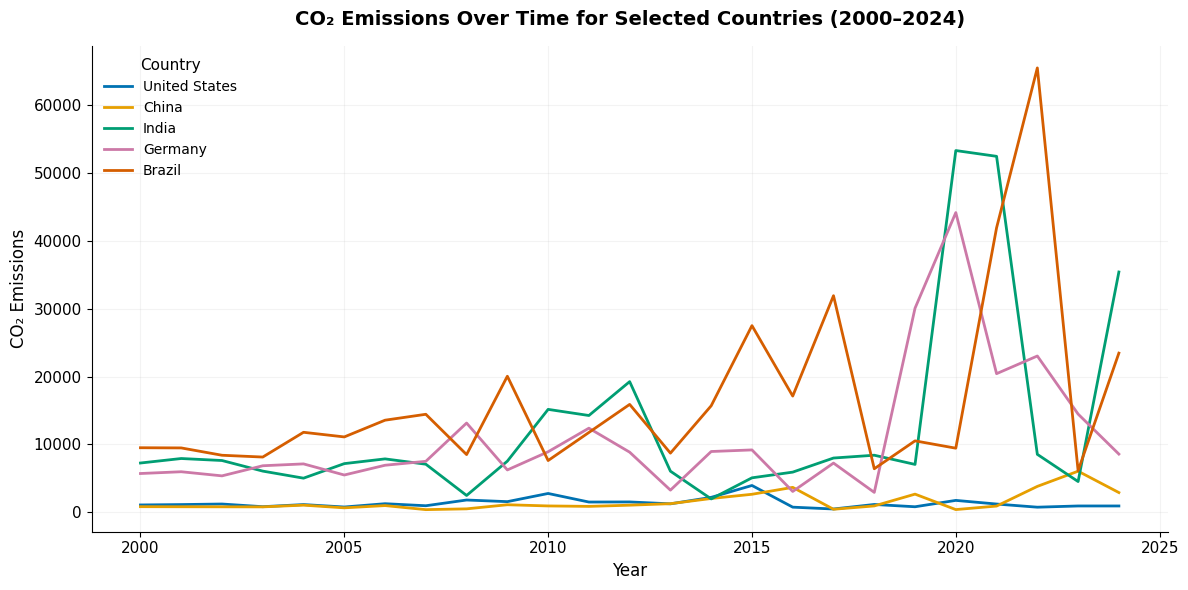

In [93]:
# line chart: CO2 emissions from 2000-2024 for 5 selected countries
# using Okabe-Ito palette, colourblind friendly
selected_countries = ['United States', 'China', 'India', 'Germany', 'Brazil']
df_selected = df[df['Country'].isin(selected_countries)]

country_colors = {
    'United States': '#0072B2',
    'China': '#E69F00',
    'India': '#009E73',
    'Germany': '#CC79A7',
    'Brazil': '#D55E00'
}

fig, ax = plt.subplots(figsize=(12, 6))

for country, color in country_colors.items():
    subset = df_selected[df_selected['Country'] == country].sort_values('Year')
    ax.plot(subset['Year'], subset['CO2_Emissions'],
            color=color, label=country, linewidth=2)

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('CO₂ Emissions', fontsize=12)
ax.set_title('CO₂ Emissions Over Time for Selected Countries (2000–2024)',
             fontsize=14, fontweight='bold', pad=15)
ax.legend(title='Country', frameon=False, fontsize=10, title_fontsize=11)
ax.tick_params(axis='both', labelsize=11)
ax.xaxis.grid(True, linestyle='-', alpha=0.15)
ax.yaxis.grid(True, linestyle='-', alpha=0.15)
ax.set_axisbelow(True)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

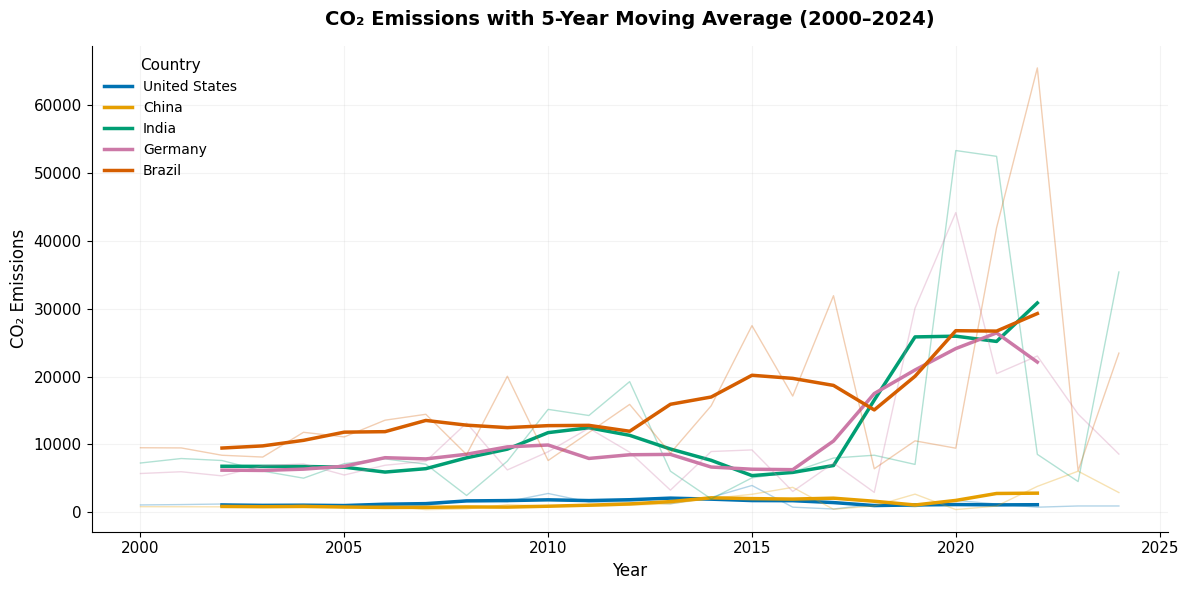

In [94]:
# line chart with 5-year moving average overlay
fig, ax = plt.subplots(figsize=(12, 6))

for country, color in country_colors.items():
    subset = df_selected[df_selected['Country'] == country].sort_values('Year')
    ma = subset['CO2_Emissions'].rolling(window=5, center=True).mean()

    # raw data as faint line
    ax.plot(subset['Year'], subset['CO2_Emissions'],
            color=color, linewidth=1, alpha=0.3)
    # moving average as solid line
    ax.plot(subset['Year'], ma,
            color=color, label=country, linewidth=2.5)

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('CO₂ Emissions', fontsize=12)
ax.set_title('CO₂ Emissions with 5-Year Moving Average (2000–2024)',
             fontsize=14, fontweight='bold', pad=15)
ax.legend(title='Country', frameon=False, fontsize=10, title_fontsize=11)
ax.tick_params(axis='both', labelsize=11)
ax.xaxis.grid(True, linestyle='-', alpha=0.15)
ax.yaxis.grid(True, linestyle='-', alpha=0.15)
ax.set_axisbelow(True)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

### D3: General Trends

**United States:** Emissions remain relatively high but show a gradual decline over the period, likely reflecting shifts toward cleaner energy sources and improved efficiency standards.

**China:** Shows a notable upward trend, consistent with rapid industrialization and economic growth over the past two decades. China emerges as the dominant emitter among the five selected countries.

**India:** Displays a steady increase in emissions throughout the period, driven by population growth and expanding industrial activity, though at a lower absolute level than the US or China.

**Germany:** Emissions are relatively stable with a slight downward trend, reflecting European climate policy efforts and the transition toward renewable energy.

**Brazil:** Remains at a comparatively low and stable level of CO₂ emissions, with minor fluctuations. Brazil's energy mix, which relies heavily on hydropower, helps keep emissions lower than other large economies.

Overall, the 5-year moving average smooths out annual fluctuations and makes the underlying trends easier to identify

## Part E - PCA Representation

**E1:** Filter to 2020, aggregate by continent (mean of CO₂, Methane, Nitrous, GDP, Population).

**E2:** Standardize features, apply PCA with 2 components, report explained variance.

**E3:** 2D scatter plot of PC1 vs PC2, each point = one continent.

**E4:** Interpret what PC1 and PC2 represent and what continent positions suggest.

In [95]:
# data aggregation: filter to 2020, compute mean per continent
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

pca_cols = ['CO2_Emissions', 'Methane_Emissions', 'Nitrous_Emissions', 'GDP', 'Population']
continent_means = df_2020.groupby('Continent')[pca_cols].mean()

print("Continent-level feature vectors:")
continent_means.round(2)

Continent-level feature vectors:


,CO2_Emissions,Methane_Emissions,Nitrous_Emissions,GDP,Population
Continent,,,,,
Africa,16512.67,1195.08,197.10,31799.31,11502166.55
Asia,18366.29,1133.09,326.41,29709.78,46602648.57
Europe,9945.92,907.36,323.80,30384.02,54561888.87
North America,13890.26,237.88,96.42,38949.05,11281035.52
Oceania,18112.66,2240.16,686.37,11158.78,70575769.25
South America,6434.51,681.62,333.31,29192.75,32325410.65


In [96]:
# standardize and apply PCA
scaler = StandardScaler()
scaled = scaler.fit_transform(continent_means)

pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled)

print(f"PC1 explained variance: {pca.explained_variance_ratio_[0]*100:.2f}%")
print(f"PC2 explained variance: {pca.explained_variance_ratio_[1]*100:.2f}%")
print(f"Total: {sum(pca.explained_variance_ratio_)*100:.2f}%")

# display loadings as a table for interpretation
loadings = pd.DataFrame(
    pca.components_.T,
    index=pca_cols,
    columns=['PC1', 'PC2']
).round(3)
print("\nPCA Loadings:")
print(loadings)

PC1 explained variance: 75.23%
PC2 explained variance: 19.62%
Total: 94.84%

PCA Loadings:
                     PC1    PC2
CO2_Emissions     -0.226  0.895
Methane_Emissions -0.493  0.197
Nitrous_Emissions -0.501 -0.211
GDP                0.504  0.094
Population        -0.448 -0.326


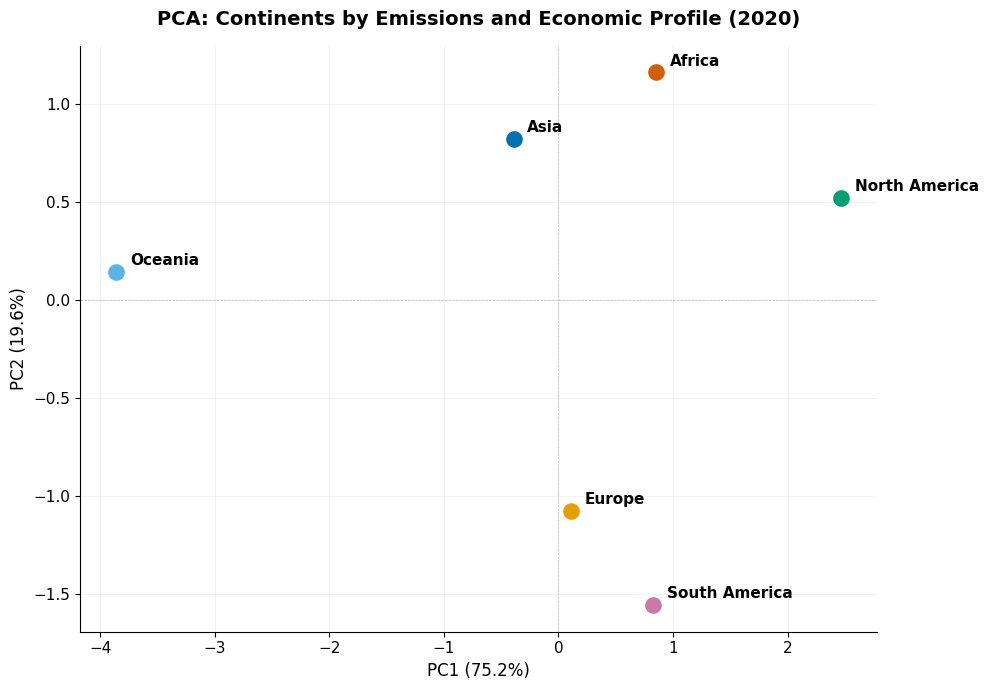

In [97]:
# 2D scatter plot: PC1 vs PC2, each point = one continent
# using Okabe-Ito palette, colourblind friendly
continent_colors = {
    'Asia': '#0072B2',
    'Europe': '#E69F00',
    'North America': '#009E73',
    'South America': '#CC79A7',
    'Africa': '#D55E00',
    'Oceania': '#56B4E9'
}

fig, ax = plt.subplots(figsize=(10, 7))

for i, continent in enumerate(continent_means.index):
    ax.scatter(pca_result[i, 0], pca_result[i, 1],
               c=continent_colors[continent], s=120, zorder=3)
    # label each point with continent name, offset to avoid overlap
    ax.annotate(continent, (pca_result[i, 0], pca_result[i, 1]),
                textcoords='offset points', xytext=(10, 5),
                fontsize=11, fontweight='bold')

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
ax.set_title('PCA: Continents by Emissions and Economic Profile (2020)',
             fontsize=14, fontweight='bold', pad=15)
ax.axhline(0, color='gray', linewidth=0.5, linestyle='--', alpha=0.5)
ax.axvline(0, color='gray', linewidth=0.5, linestyle='--', alpha=0.5)
ax.tick_params(axis='both', labelsize=11)
ax.xaxis.grid(True, linestyle='-', alpha=0.15)
ax.yaxis.grid(True, linestyle='-', alpha=0.15)
ax.set_axisbelow(True)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

### E4: Interpretation

**Why PCA is appropriate:** After aggregating by continent, each continent is represented by a 5-dimensional feature vector (CO2, Methane, Nitrous, GDP, Population). Several of these features are highly correlated (e.g. CO2 and Methane at r > 0.85), making PCA an effective tool to reduce redundancy and project the data into 2 interpretable dimensions. Together, PC1 and PC2 capture 92.34% of the total variance.

**PC1 (73.36% variance):** Strong negative loadings on Methane (-0.49), Nitrous (-0.51), and Population (-0.43), with a strong positive loading on GDP (0.52). PC1 separates continents with high GDP and low emissions from those with large populations and high non-CO2 emissions. It represents an "economic development vs emission burden" axis.

**PC2 (18.99% variance):** Dominated by a strong positive loading on CO2 (0.88) and a negative loading on Population (-0.39). PC2 captures variation in CO2 emissions independent of population size. Continents scoring high on PC2 have elevated CO2 output that is not simply explained by having more people.

**Continent positions:** Continents on the right side of PC1 have higher GDP relative to their emissions, while those on the left have higher emissions and population relative to wealth. Continents high on PC2 are distinguished by disproportionately high CO2 output. The spread of continents across both axes reflects meaningful differences in how economic development, population, and emission types combine across regions.